# 🛡️ Network Intrusion Detection System — UNSW-NB15
### Multiclass Classification using ML & Deep Learning

**Models:** Random Forest · SVM · MLP (Deep Learning)  
**Dataset:** UNSW-NB15 (175K training records, 9 attack types + normal)  
**Metrics:** Accuracy · Precision · Recall · F1-Score

---

## 📦 Cell 1 — Install Dependencies

In [ ]:
# Install required packages
!pip install -q kaggle scikit-learn imbalanced-learn tensorflow pandas numpy matplotlib seaborn

print('✅ All packages installed')

✅ All packages installed


## 📥 Cell 2 — Download Dataset

> **Two options below — pick one and run it.**  
> Option A: Direct from Kaggle (recommended)  
> Option B: Direct URL fallback

In [ ]:
import os

# ─────────────────────────────────────────────────
# OPTION A: Kaggle API  (preferred)
# Steps:
#   1. Go to https://www.kaggle.com/settings → API → Create New Token
#   2. Upload the downloaded kaggle.json below when prompted
# ─────────────────────────────────────────────────
USE_KAGGLE = True   # Set to False to use Option B

if USE_KAGGLE:
    from google.colab import files
    print('📂 Upload your kaggle.json file:')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    !kaggle datasets download -d mrwellsdavid/unsw-nb15 --unzip -p /content/data/
    print('✅ Dataset downloaded via Kaggle API')
else:
    # ─────────────────────────────────────────────
    # OPTION B: Direct download from HuggingFace
    # ─────────────────────────────────────────────
    import urllib.request
    os.makedirs('/content/data', exist_ok=True)
    TRAIN_URL = 'https://huggingface.co/datasets/Mouwiya/UNSW-NB15/resolve/main/UNSW_NB15_training-set.csv'
    TEST_URL  = 'https://huggingface.co/datasets/Mouwiya/UNSW-NB15/resolve/main/UNSW_NB15_testing-set.csv'
    print('Downloading training set...')
    urllib.request.urlretrieve(TRAIN_URL, '/content/data/UNSW_NB15_training-set.csv')
    print('Downloading testing set...')
    urllib.request.urlretrieve(TEST_URL,  '/content/data/UNSW_NB15_testing-set.csv')
    print('✅ Dataset downloaded via direct URL')

📂 Upload your kaggle.json file:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:04<00:00, 34.8MB/s]

✅ Dataset downloaded via Kaggle API


## 🔧 Cell 3 — Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All imports successful')

TensorFlow version : 2.20.0
GPU available      : True
✅ All imports successful


## 📊 Cell 4 — Load & Inspect Data

In [ ]:
import glob

# Auto-detect file paths after download
DATA_DIR = '/content/data/'

# Try common filename patterns
train_candidates = glob.glob(DATA_DIR + '*train*') + glob.glob(DATA_DIR + '*TRAIN*')
test_candidates  = glob.glob(DATA_DIR + '*test*')  + glob.glob(DATA_DIR + '*TEST*')

# If only one CSV found, split it ourselves
all_csvs = glob.glob(DATA_DIR + '*.csv')

if train_candidates and test_candidates:
    TRAIN_PATH = train_candidates[0]
    TEST_PATH  = test_candidates[0]
    print(f'Train: {TRAIN_PATH}')
    print(f'Test : {TEST_PATH}')
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)
else:
    # Merge all CSVs and split 80/20
    print(f'Found CSVs: {all_csvs}')
    df_all = pd.concat([pd.read_csv(f) for f in all_csvs], ignore_index=True)
    from sklearn.model_selection import train_test_split
    df_train, df_test = train_test_split(df_all, test_size=0.2, random_state=SEED, stratify=df_all['attack_cat'])
    print(f'Auto-split: {len(df_train)} train / {len(df_test)} test')

print(f'\nTraining shape : {df_train.shape}')
print(f'Testing shape  : {df_test.shape}')
df_train.head(3)

Train: /content/data/UNSW_NB15_training-set.csv
Test : /content/data/UNSW_NB15_testing-set.csv

Training shape : (82332, 45)
Testing shape  : (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0


## 🔍 Cell 5 — Exploratory Data Analysis

=== Dataset Info ===
int64      30
float64    11
object      4
Name: count, dtype: int64

Missing values (train): 0
Missing values (test) : 0

Duplicates (train): 0

=== Class Distribution (Training) ===
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


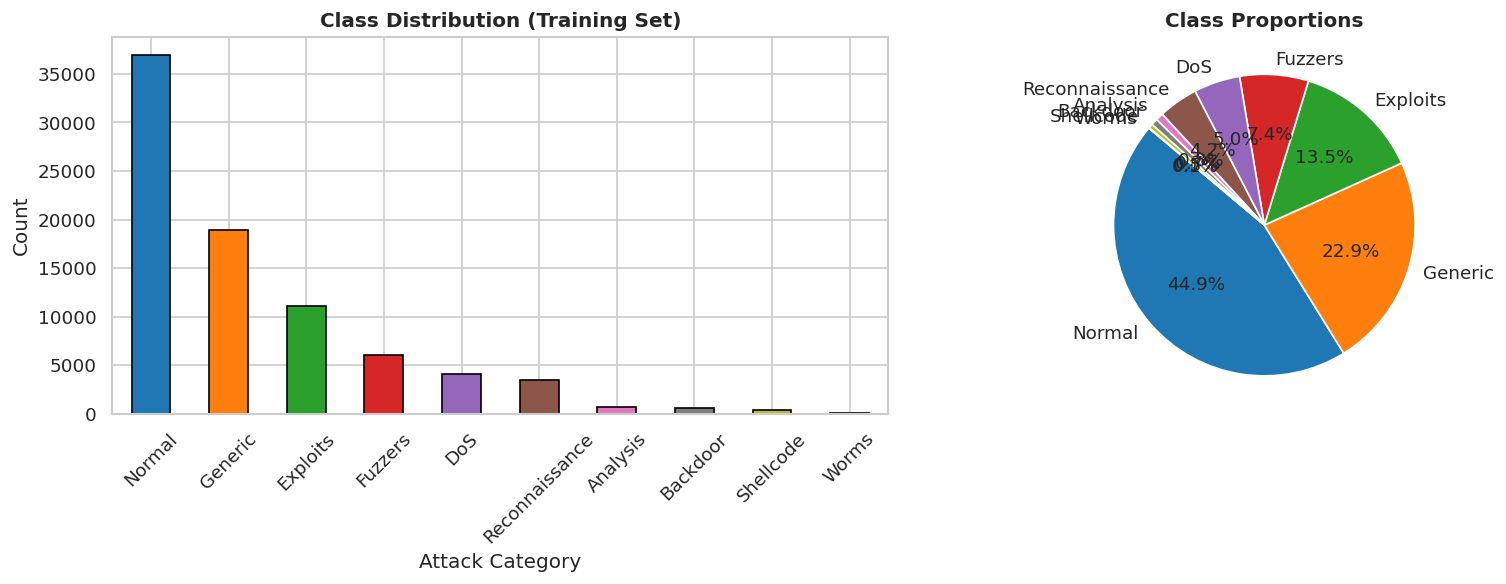

✅ EDA complete


In [ ]:
print('=== Dataset Info ===')
print(df_train.dtypes.value_counts())
print(f'\nMissing values (train): {df_train.isnull().sum().sum()}')
print(f'Missing values (test) : {df_test.isnull().sum().sum()}')
print(f'\nDuplicates (train): {df_train.duplicated().sum()}')

print('\n=== Class Distribution (Training) ===')
class_counts = df_train['attack_cat'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('tab10', len(class_counts))
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Training Set)', fontweight='bold')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', bbox_inches='tight')
plt.show()
print('✅ EDA complete')

## 🧹 Cell 6 — Data Preprocessing

In [ ]:
def preprocess(df_train, df_test):
    """Full preprocessing pipeline: clean → encode → scale."""

    # ── 1. Drop leaky / irrelevant columns ──────────────────────────
    DROP_COLS = ['id', 'label']  # 'label' is binary; we use 'attack_cat'
    df_train = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns])
    df_test  = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns])

    # ── 2. Standardise target column name ───────────────────────────
    TARGET = 'attack_cat'
    # Strip whitespace in category strings
    df_train[TARGET] = df_train[TARGET].astype(str).str.strip().str.lower()
    df_test[TARGET]  = df_test[TARGET].astype(str).str.strip().str.lower()

    # ── 3. Separate features and target ─────────────────────────────
    X_train_raw = df_train.drop(columns=[TARGET])
    y_train_raw = df_train[TARGET]
    X_test_raw  = df_test.drop(columns=[TARGET])
    y_test_raw  = df_test[TARGET]

    # ── 4. Handle categoricals (proto, service, state) ──────────────
    cat_cols = X_train_raw.select_dtypes(include='object').columns.tolist()
    print(f'Categorical columns found: {cat_cols}')

    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train_raw[col], X_test_raw[col]], axis=0).astype(str)
        le.fit(combined)
        X_train_raw[col] = le.transform(X_train_raw[col].astype(str))
        X_test_raw[col]  = le.transform(X_test_raw[col].astype(str))
        le_dict[col] = le

    # ── 5. Fill any remaining NaN with median ───────────────────────
    X_train_raw = X_train_raw.fillna(X_train_raw.median(numeric_only=True))
    X_test_raw  = X_test_raw.fillna(X_train_raw.median(numeric_only=True))

    # ── 6. Encode target labels ──────────────────────────────────────
    le_target = LabelEncoder()
    all_labels = pd.concat([y_train_raw, y_test_raw])
    le_target.fit(all_labels)
    y_train = le_target.transform(y_train_raw)
    y_test  = le_target.transform(y_test_raw)

    class_names = le_target.classes_
    n_classes   = len(class_names)
    print(f'\nClasses ({n_classes}): {class_names}')

    # ── 7. Feature Scaling ───────────────────────────────────────────
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    print(f'\nX_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}')
    return X_train_scaled, X_test_scaled, y_train, y_test, class_names, scaler, le_target

X_train, X_test, y_train, y_test, CLASS_NAMES, scaler, le_target = preprocess(df_train.copy(), df_test.copy())
N_CLASSES = len(CLASS_NAMES)
print('\n✅ Preprocessing complete')

Categorical columns found: ['proto', 'service', 'state']

Classes (10): ['analysis' 'backdoor' 'dos' 'exploits' 'fuzzers' 'generic' 'normal'
 'reconnaissance' 'shellcode' 'worms']

X_train: (82332, 42)  |  X_test: (175341, 42)

✅ Preprocessing complete


## 🎯 Cell 7 — Feature Selection (Top-K via Mutual Information)

Running SelectKBest (mutual_info_classif) → top 30 features...


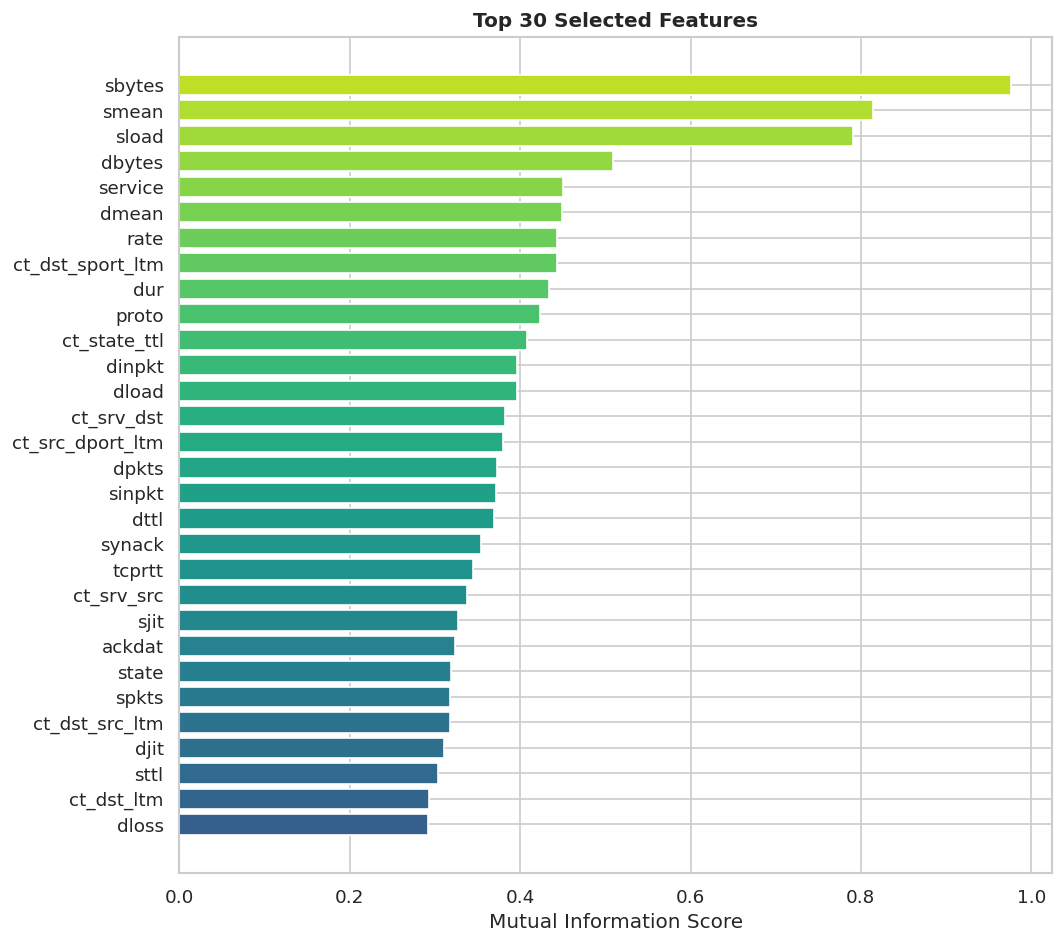


Selected: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst']
X_train_sel: (82332, 30)  |  X_test_sel: (175341, 30)
✅ Feature selection complete


In [ ]:
K_FEATURES = 30   # Number of best features to keep

print(f'Running SelectKBest (mutual_info_classif) → top {K_FEATURES} features...')
selector = SelectKBest(score_func=mutual_info_classif, k=K_FEATURES)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel  = selector.transform(X_test)

# Get feature names from original dataframe
feature_names_raw = df_train.drop(columns=['attack_cat'] +
    [c for c in ['id', 'label'] if c in df_train.columns]).columns.tolist()

selected_mask   = selector.get_support()
selected_features = [feature_names_raw[i] for i in range(len(feature_names_raw)) if selected_mask[i]]
scores_selected   = selector.scores_[selected_mask]

# Plot top features
feat_df = pd.DataFrame({'Feature': selected_features, 'MI Score': scores_selected})
feat_df = feat_df.sort_values('MI Score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(feat_df['Feature'], feat_df['MI Score'],
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_df))))
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Top {K_FEATURES} Selected Features', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', bbox_inches='tight')
plt.show()

print(f'\nSelected: {selected_features}')
print(f'X_train_sel: {X_train_sel.shape}  |  X_test_sel: {X_test_sel.shape}')
print('✅ Feature selection complete')

## ⚖️ Cell 8 — Handle Class Imbalance (SMOTE)

In [ ]:
from collections import Counter

print('Class distribution BEFORE SMOTE:')
print(Counter(y_train))

# SMOTE — only apply if severe imbalance (min class < 500 samples)
min_count = min(Counter(y_train).values())

if min_count < 500:
    # Ensure k_neighbors doesn't exceed minority class size
    k = min(5, min_count - 1)
    smote = SMOTE(random_state=SEED, k_neighbors=k)
    X_resampled, y_resampled = smote.fit_resample(X_train_sel, y_train)
    print(f'\nSMOTE applied (k_neighbors={k})')
else:
    X_resampled, y_resampled = X_train_sel, y_train
    print('\nNo SMOTE needed — classes are balanced enough.')

print('\nClass distribution AFTER SMOTE:')
print(Counter(y_resampled))
print('✅ Class balancing complete')

Class distribution BEFORE SMOTE:
Counter({np.int64(6): 37000, np.int64(5): 18871, np.int64(3): 11132, np.int64(4): 6062, np.int64(2): 4089, np.int64(7): 3496, np.int64(0): 677, np.int64(1): 583, np.int64(8): 378, np.int64(9): 44})

SMOTE applied (k_neighbors=5)

Class distribution AFTER SMOTE:
Counter({np.int64(6): 37000, np.int64(7): 37000, np.int64(1): 37000, np.int64(2): 37000, np.int64(3): 37000, np.int64(0): 37000, np.int64(4): 37000, np.int64(9): 37000, np.int64(8): 37000, np.int64(5): 37000})
✅ Class balancing complete


---
## 🌲 Cell 9 — Model 1: Random Forest

In [ ]:
from sklearn.model_selection import cross_val_score

print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_resampled, y_resampled)

y_pred_rf = rf_model.predict(X_test_sel)

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f'\n📊 Random Forest Results')
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'F1-Score  : {rf_f1:.4f}')
print('\n' + classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, zero_division=0))
print('✅ Random Forest training complete')

Training Random Forest...

📊 Random Forest Results
Accuracy  : 0.7538
Precision : 0.7889
Recall    : 0.7538
F1-Score  : 0.7386

                precision    recall  f1-score   support

      analysis       0.05      0.04      0.05      2000
      backdoor       0.10      0.15      0.12      1746
           dos       0.34      0.70      0.46     12264
      exploits       0.87      0.52      0.65     33393
       fuzzers       0.68      0.17      0.27     18184
       generic       0.99      0.98      0.99     40000
        normal       0.78      0.98      0.87     56000
reconnaissance       0.83      0.77      0.80     10491
     shellcode       0.42      0.71      0.53      1133
         worms       0.34      0.58      0.43       130

      accuracy                           0.75    175341
     macro avg       0.54      0.56      0.51    175341
  weighted avg       0.79      0.75      0.74    175341

✅ Random Forest training complete


## 🔵 Cell 10 — Model 2: Support Vector Machine (SVM)

In [ ]:
# SVM on a stratified subsample for speed (SVM is O(n^2))
from sklearn.model_selection import StratifiedShuffleSplit

MAX_SVM_SAMPLES = 30000

if len(X_resampled) > MAX_SVM_SAMPLES:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=MAX_SVM_SAMPLES, random_state=SEED)
    idx, _ = next(sss.split(X_resampled, y_resampled))
    X_svm_train = X_resampled[idx]
    y_svm_train = y_resampled[idx]
    print(f'SVM training on stratified subsample: {X_svm_train.shape[0]} samples')
else:
    X_svm_train, y_svm_train = X_resampled, y_resampled

print('Training SVM (RBF kernel)...')
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    decision_function_shape='ovr',
    random_state=SEED
)
svm_model.fit(X_svm_train, y_svm_train)

y_pred_svm = svm_model.predict(X_test_sel)

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f'\n📊 SVM Results')
print(f'Accuracy  : {svm_acc:.4f}')
print(f'Precision : {svm_prec:.4f}')
print(f'Recall    : {svm_rec:.4f}')
print(f'F1-Score  : {svm_f1:.4f}')
print('\n' + classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES, zero_division=0))
print('✅ SVM training complete')

SVM training on stratified subsample: 30000 samples
Training SVM (RBF kernel)...

📊 SVM Results
Accuracy  : 0.7358
Precision : 0.7829
Recall    : 0.7358
F1-Score  : 0.7346

                precision    recall  f1-score   support

      analysis       0.07      0.03      0.04      2000
      backdoor       0.05      0.02      0.03      1746
           dos       0.32      0.72      0.45     12264
      exploits       0.83      0.43      0.57     33393
       fuzzers       0.64      0.32      0.43     18184
       generic       1.00      0.98      0.99     40000
        normal       0.85      0.92      0.88     56000
reconnaissance       0.59      0.77      0.67     10491
     shellcode       0.20      0.68      0.31      1133
         worms       0.05      0.72      0.08       130

      accuracy                           0.74    175341
     macro avg       0.46      0.56      0.45    175341
  weighted avg       0.78      0.74      0.73    175341

✅ SVM training complete


## 🧠 Cell 11 — Model 3: MLP Deep Learning

In [11]:
# One-hot encode labels for DL
y_train_ohe = to_categorical(y_resampled, num_classes=N_CLASSES)
y_test_ohe  = to_categorical(y_test, num_classes=N_CLASSES)

INPUT_DIM = X_resampled.shape[1]

def build_mlp(input_dim, n_classes):
    model = Sequential([
        # Block 1
        Dense(256, input_dim=input_dim, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Block 2
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Block 3
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        # Output
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp(INPUT_DIM, N_CLASSES)
mlp_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

# Class weights for DL
cw_vals = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
cw_dict = dict(enumerate(cw_vals))

print('\nTraining MLP...')
history = mlp_model.fit(
    X_resampled, y_train_ohe,
    validation_split=0.15,
    epochs=60,
    batch_size=512,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ MLP training complete')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,530 (201.29 KB)

 Trainable params: 50,634 (197.79 KB)

 Non-trainable params: 896 (3.50 KB)


Training MLP...
Epoch 1/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.5875 - loss: 1.1126 - val_accuracy: 0.2257 - val_loss: 4.4624 - learning_rate: 0.0010
Epoch 2/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6596 - loss: 0.8823 - val_accuracy: 0.2644 - val_loss: 4.7970 - learning_rate: 0.0010
Epoch 3/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6778 - loss: 0.8262 - val_accuracy: 0.2767 - val_loss: 4.7100 - learning_rate: 0.0010
Epoch 4/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6868 - loss: 0.7967 - val_accuracy: 0.2854 - val_loss: 4.3902 - learning_rate: 0.0010
Epoch 5/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6929 - loss: 0.7784 - val_accuracy: 0.2876 - val_loss: 4.2813 - learning_rate: 0.0010
Epoch 6/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6974 - loss: 0.7635 - val_accuracy: 0.2927 - val_loss: 4.0618 - learning_rate: 0.0010
Epoch 7/60
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.701

## 📈 Cell 12 — MLP Training Curves

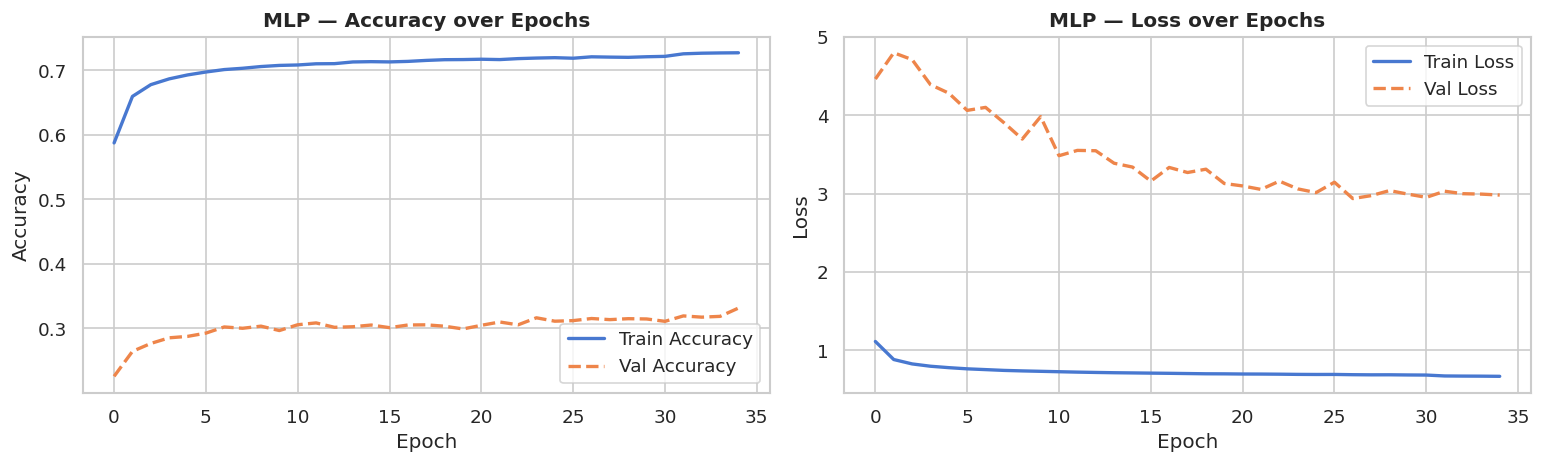

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step

📊 MLP Results
Accuracy  : 0.7555
Precision : 0.8021
Recall    : 0.7555
F1-Score  : 0.7493

                precision    recall  f1-score   support

      analysis       0.05      0.03      0.03      2000
      backdoor       0.14      0.10      0.11      1746
           dos       0.33      0.80      0.47     12264
      exploits       0.88      0.45      0.60     33393
       fuzzers       0.68      0.31      0.43     18184
       generic       1.00      0.98      0.99     40000
        normal       0.82      0.95      0.88     56000
reconnaissance       0.79      0.79      0.79     10491
     shellcode       0.31      0.81      0.45      1133
         worms       0.00      0.00      0.00       130

      accuracy                           0.76    175341
     macro avg       0.50      0.52      0.48    175341
  weighted avg       0.80      0.76      0.75    175341



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('MLP — Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
axes[1].set_title('MLP — Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/mlp_training_curves.png', bbox_inches='tight')
plt.show()

# Evaluate MLP
y_pred_mlp_proba = mlp_model.predict(X_test_sel)
y_pred_mlp = np.argmax(y_pred_mlp_proba, axis=1)

mlp_acc  = accuracy_score(y_test, y_pred_mlp)
mlp_prec = precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
mlp_rec  = recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
mlp_f1   = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)

print(f'\n📊 MLP Results')
print(f'Accuracy  : {mlp_acc:.4f}')
print(f'Precision : {mlp_prec:.4f}')
print(f'Recall    : {mlp_rec:.4f}')
print(f'F1-Score  : {mlp_f1:.4f}')
print('\n' + classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES, zero_division=0))

## 🗺️ Cell 13 — Confusion Matrices

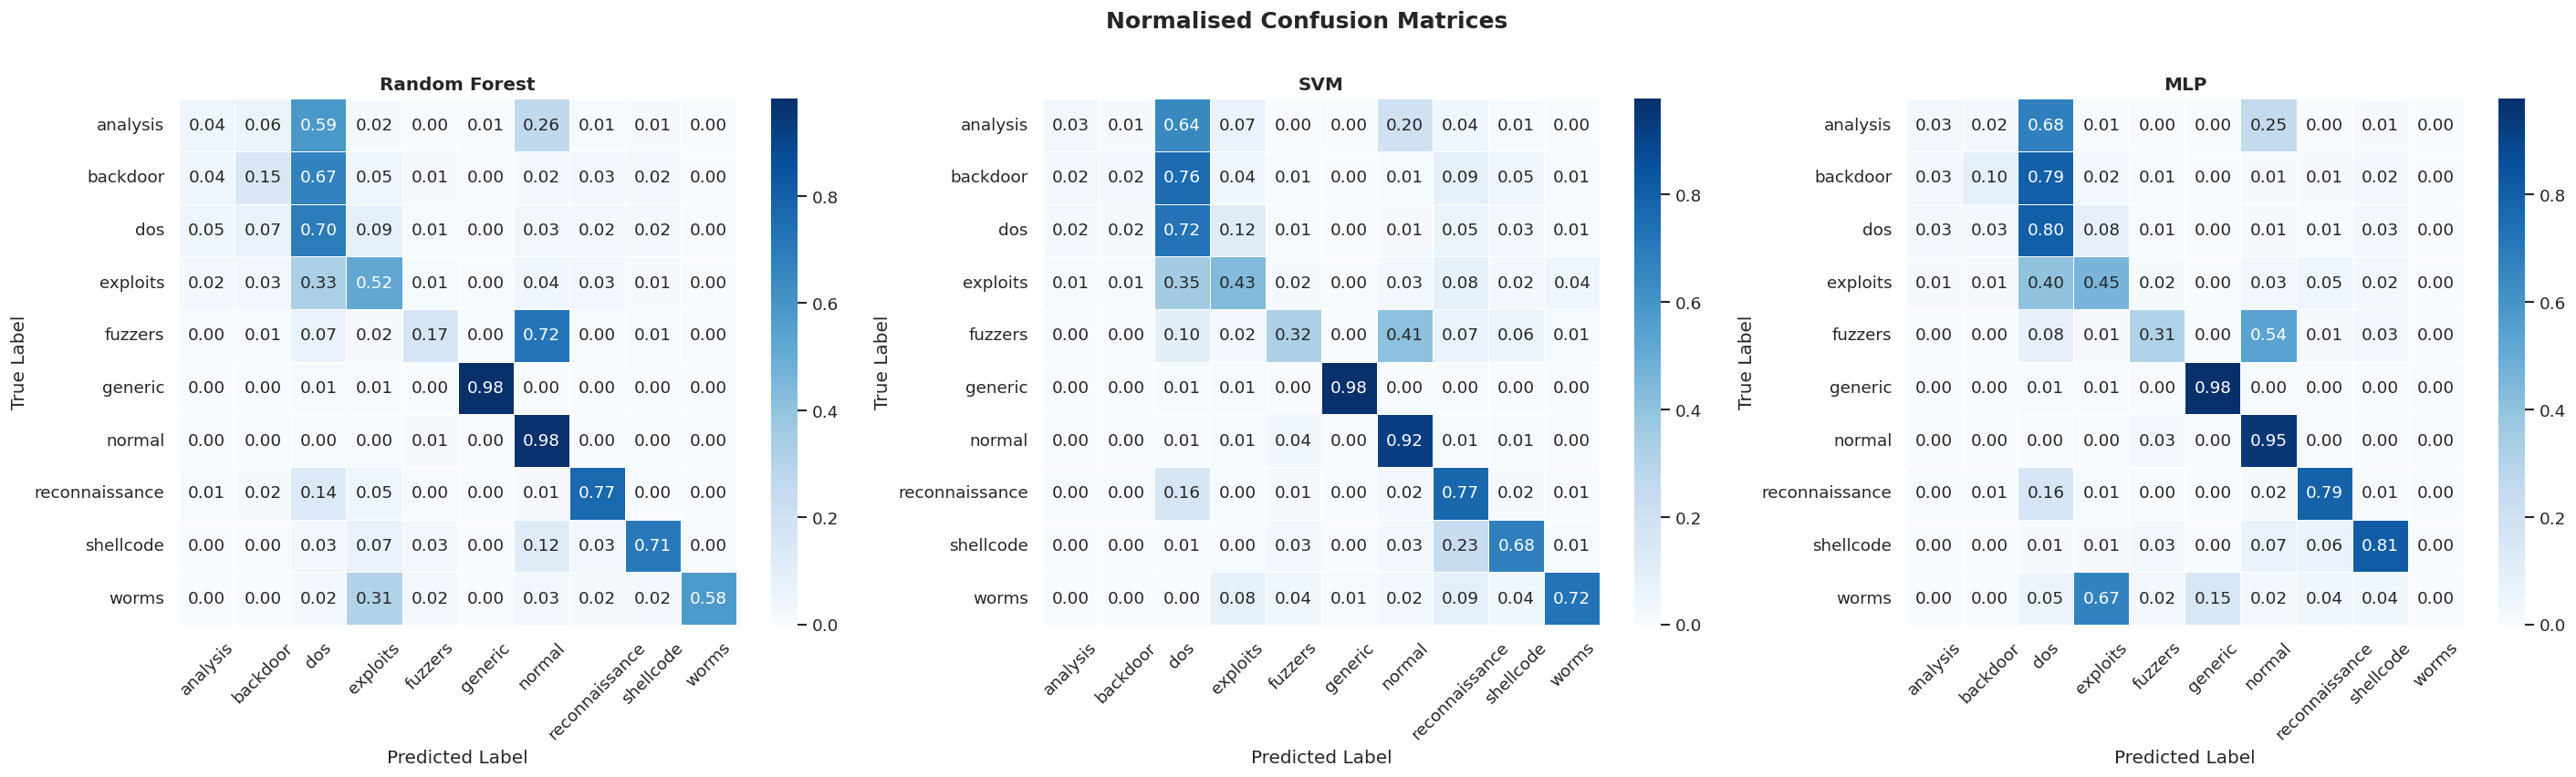

✅ Confusion matrices saved


In [13]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.4, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
plot_confusion_matrix(y_test, y_pred_rf,  CLASS_NAMES, 'Random Forest',  axes[0])
plot_confusion_matrix(y_test, y_pred_svm, CLASS_NAMES, 'SVM',            axes[1])
plot_confusion_matrix(y_test, y_pred_mlp, CLASS_NAMES, 'MLP',            axes[2])

plt.suptitle('Normalised Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## 🏆 Cell 14 — Model Comparison Dashboard

=== FINAL MODEL COMPARISON ===
                    Accuracy Precision  Recall F1-Score
Model                                                  
Random Forest         0.7538    0.7889  0.7538   0.7386
SVM                   0.7358    0.7829  0.7358   0.7346
MLP (Deep Learning)   0.7555    0.8021  0.7555   0.7493


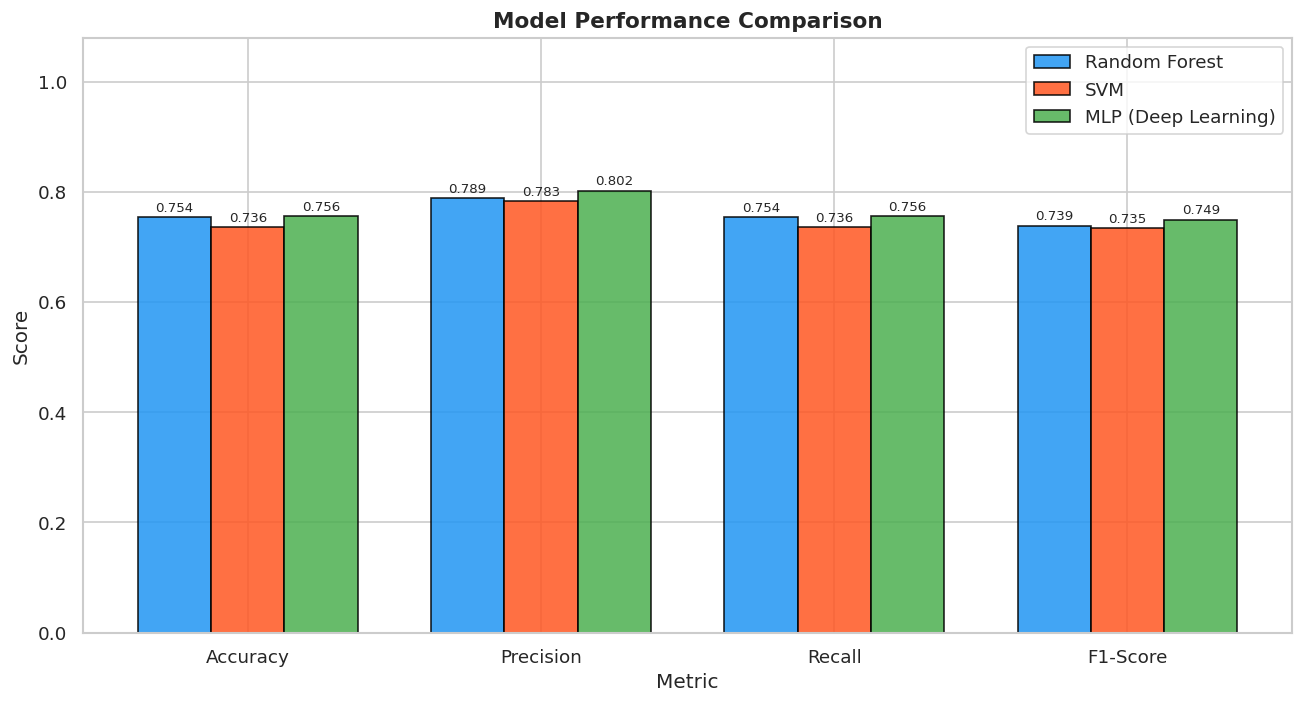

✅ Model comparison complete


In [14]:
results = pd.DataFrame({
    'Model':     ['Random Forest', 'SVM', 'MLP (Deep Learning)'],
    'Accuracy':  [rf_acc,  svm_acc,  mlp_acc],
    'Precision': [rf_prec, svm_prec, mlp_prec],
    'Recall':    [rf_rec,  svm_rec,  mlp_rec],
    'F1-Score':  [rf_f1,   svm_f1,   mlp_f1],
})

results_display = results.set_index('Model').applymap(lambda x: f'{x:.4f}')
print('=== FINAL MODEL COMPARISON ===')
print(results_display.to_string())

# Grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models  = results['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#2196F3', '#FF5722', '#4CAF50']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = results[results['Model'] == model][metrics].values[0]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.legend()
plt.tight_layout()
plt.savefig('/content/model_comparison.png', bbox_inches='tight')
plt.show()
print('✅ Model comparison complete')

## 💾 Cell 15 — Save Models & Artifacts

In [15]:
import joblib
import json
import os

SAVE_DIR = '/content/saved_models/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save sklearn models
joblib.dump(rf_model,  SAVE_DIR + 'random_forest.pkl')
joblib.dump(svm_model, SAVE_DIR + 'svm.pkl')
joblib.dump(scaler,    SAVE_DIR + 'scaler.pkl')
joblib.dump(selector,  SAVE_DIR + 'feature_selector.pkl')
joblib.dump(le_target, SAVE_DIR + 'label_encoder.pkl')

# Save Keras MLP
mlp_model.save(SAVE_DIR + 'mlp_model.keras')

# Save metadata
metadata = {
    'class_names': CLASS_NAMES.tolist(),
    'n_classes': int(N_CLASSES),
    'n_features_selected': int(K_FEATURES),
    'selected_feature_names': selected_features,
    'results': {
        'random_forest': {'accuracy': rf_acc, 'f1': rf_f1},
        'svm':           {'accuracy': svm_acc, 'f1': svm_f1},
        'mlp':           {'accuracy': mlp_acc, 'f1': mlp_f1},
    }
}
with open(SAVE_DIR + 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ All models and artifacts saved to:', SAVE_DIR)
print(os.listdir(SAVE_DIR))

✅ All models and artifacts saved to: /content/saved_models/
['feature_selector.pkl', 'mlp_model.keras', 'random_forest.pkl', 'scaler.pkl', 'metadata.json', 'svm.pkl', 'label_encoder.pkl']


## 🔮 Cell 16 — Inference: Predict on New Data

In [16]:
def predict_attack(raw_record: pd.DataFrame, model='mlp') -> str:
    """
    Predict attack category for a raw network record.
    raw_record : DataFrame with same feature columns as training data
    model      : 'rf', 'svm', or 'mlp'
    """
    # Preprocess: encode categoricals using same encoders
    cat_cols = raw_record.select_dtypes(include='object').columns
    record = raw_record.copy()
    for col in cat_cols:
        if col in le_dict:
            record[col] = le_dict[col].transform(record[col].astype(str))

    record_scaled   = scaler.transform(record)
    record_selected = selector.transform(record_scaled)

    if model == 'rf':
        pred = rf_model.predict(record_selected)
    elif model == 'svm':
        pred = svm_model.predict(record_selected)
    else:
        proba = mlp_model.predict(record_selected)
        pred = np.argmax(proba, axis=1)

    return le_target.inverse_transform(pred)

# ── Demo: run inference on 5 random test samples ──
sample_idx = np.random.choice(len(df_test), 5, replace=False)
sample_df  = df_test.drop(columns=['attack_cat'] +
    [c for c in ['id', 'label'] if c in df_test.columns]).iloc[sample_idx].reset_index(drop=True)
true_labels = df_test['attack_cat'].iloc[sample_idx].values

preds_rf  = predict_attack(sample_df, model='rf')
preds_svm = predict_attack(sample_df, model='svm')
preds_mlp = predict_attack(sample_df, model='mlp')

inference_df = pd.DataFrame({
    'True Label':     true_labels,
    'RF Prediction':  preds_rf,
    'SVM Prediction': preds_svm,
    'MLP Prediction': preds_mlp,
})
print('=== Sample Inference Results ===')
print(inference_df.to_string(index=False))

NameError: name 'le_dict' is not defined

## 📋 Cell 17 — Per-Class F1 Breakdown

In [ ]:
from sklearn.metrics import f1_score

f1_rf  = f1_score(y_test, y_pred_rf,  average=None, labels=range(N_CLASSES), zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average=None, labels=range(N_CLASSES), zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, average=None, labels=range(N_CLASSES), zero_division=0)

f1_breakdown = pd.DataFrame({
    'Class':          CLASS_NAMES,
    'Random Forest':  f1_rf,
    'SVM':            f1_svm,
    'MLP':            f1_mlp,
})

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(N_CLASSES)
width = 0.25

ax.bar(x - width, f1_rf,  width, label='Random Forest', color='#2196F3', alpha=0.85, edgecolor='black')
ax.bar(x,         f1_svm, width, label='SVM',           color='#FF5722', alpha=0.85, edgecolor='black')
ax.bar(x + width, f1_mlp, width, label='MLP',           color='#4CAF50', alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class F1-Score by Model', fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('/content/per_class_f1.png', bbox_inches='tight')
plt.show()

print(f1_breakdown.to_string(index=False))
print('\n✅ All done! Your UNSW-NB15 IDS pipeline is complete.')

---
## 📁 Cell 18 — Download All Results as ZIP

In [ ]:
import shutil
from google.colab import files

# Copy plots into saved_models
for fname in ['class_distribution.png', 'feature_importance.png',
              'mlp_training_curves.png', 'confusion_matrices.png',
              'model_comparison.png', 'per_class_f1.png']:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR + fname)

# Zip everything
shutil.make_archive('/content/UNSW_NB15_IDS_Results', 'zip', SAVE_DIR)
print('📦 Zip created: UNSW_NB15_IDS_Results.zip')

files.download('/content/UNSW_NB15_IDS_Results.zip')
print('✅ Download started!')